In [331]:
import pandas as pd
import numpy as np
import re

In [332]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# NOLA Climate: Predicting Sea Level Using Global Temperature and Precipitation

**By Mia Wilcox and Elina Xu**

This project analyzes global temperature anomaly, Louisiana precipitation, and Louisiana sea level data to determine whether climate-related variables can predict sea level changes along the Louisiana coast.

**Project Website:** [here](https://miawilcox18-hub.github.io/miawilcox.github.io/) .

# **Motivation**

Climate change is one of the most pressing global issues, particularly for coastal regions like Louisiana. Rising sea levels threaten infrastructure, ecosystems, and communities through increased flooding, land loss, and storm impact. Understanding the factors that contribute to sea level change is critical for both scientific understanding and policy planning.

From a data science perspective, this problem provides an opportunity to explore how multiple environmental variables interact over time. By analyzing temperature, precipitation, and sea level data, we can investigate whether changes in climate variables help explain variation in sea level.

Sea level rise is one of the most immediate and measurable impacts of climate change, particularly for coastal regions like Louisiana. Understanding the factors that contribute to rising sea levels is critical for predicting future environmental risks such as flooding and land loss. This project uses real-world climate data to explore whether changes in global temperature and precipitation can help explain and predict changes in sea level over time.

# **Table 1: Global Temperature Anomaly**

Originally, this project used Louisiana temperature data. However, the local temperature data fluctuated strongly by month and did not work well as a predictor of sea level. Because sea level rise is connected to global-scale climate processes, the project was revised to use global temperature anomaly instead.

This first table contains global temperature anomaly data. A temperature anomaly measures how much warmer or cooler a given year was compared to a long-term average baseline. Unlike raw temperature, anomaly values are useful for studying climate change because they show whether temperatures are above or below the expected historical average.

The original dataset contained one row per year, with columns for year and temperature anomaly. Since the sea level and precipitation datasets are organized by year and month, the global temperature data was reshaped so that each yearly anomaly value appeared once for each month of that year. This allowed all datasets to be merged using the same time variables.

The team chose global temperature anomaly instead of Louisiana temperature because sea level rise is influenced by global-scale climate processes. Rising global temperatures contribute to sea level rise through thermal expansion of ocean water and melting land ice. Therefore, global temperature anomaly is a stronger and more scientifically appropriate predictor for sea level than short-term local temperature variation.

In [333]:
temp_df = pd.read_csv("/content/drive/MyDrive/Data Colab Notebooks/global_temperature.csv") #importing louisiana temp data

temp_df.head()

,Year,Anomaly
0,1850,-0.43
1,1851,-0.16
2,1852,-0.06
3,1853,-0.16
4,1854,-0.21


# **Data Cleaning (ETL)**

In [334]:
# Rename columns to match the style of the other tidy tables
temp_df = temp_df.rename(columns={
    "Year": "year",
    "Anomaly": "global_temp_anomaly"
})

Because our other datasets are organized on a monthly basis, we will convert this dataset to match that structure. Each month of a given year will have the same temperature anomaly value. This allows us to merge all datasets together using year and month as common variables.

In [335]:
# Expand each yearly value to 12 monthly rows
temp_df = temp_df.loc[temp_df.index.repeat(12)].reset_index(drop=True)

# Create month column from 1 to 12 for each year
temp_df["month"] = list(range(1, 13)) * (len(temp_df) // 12)

# Rename columns
temp_tidy = temp_df.rename(columns={
    "global_temp_anomaly": "global_temp"
})

In [336]:
temp_df = temp_df[
    (temp_df["year"] >= 1970) & (temp_df["year"] <= 2024)
]

temp_df.head()

,year,global_temp_anomaly,month
1440,1970,0.16,1
1441,1970,0.16,2
1442,1970,0.16,3
1443,1970,0.16,4
1444,1970,0.16,5


In [337]:
print("Global Temperature Dataset Shape:", temp_tidy.shape)

print("\nData Types:") #check d types
print(temp_tidy.dtypes)

print("\nMissing Data Summary:") #check missing data
print(temp_tidy.isnull().sum())

Global Temperature Dataset Shape: (2124, 3)

Data Types:
year             int64
global_temp    float64
month            int64
dtype: object

Missing Data Summary:
year           0
global_temp    0
month          0
dtype: int64


This step verifies the structure of the sea level dataset after cleaning. The dataset contains year and month as integer variables and sea level as a numerical variable. There are no missing values, indicating that the dataset is complete and suitable for merging with the other datasets.

## **Summary Statistics**

In [338]:
temp_tidy["global_temp"].mean()

np.float64(0.057909604519774)

This statistic calculates the overall average temperature globally across the dataset. This is useful because it provides a baseline temperature level that can be compared against yearly temperatures to determine whether temperatures are increasing over time.

In [339]:
temp_tidy["global_temp"].max()

1.31

This identifies the highest recorded average maximum temperature in the dataset. Examining maximum temperatures helps determine whether extreme heat events are becoming more common or severe over time.

# **Table 2: Monthly Mean Sea Level**

This second table contains data on sea level measurements along the Louisiana coast. The dataset was obtained from the National Oceanic and Atmospheric Administration (NOAA) Tides and Currents program, which provides long-term observations from coastal tide gauge stations across the United States. Sea level values in this dataset are measured relative to a fixed reference datum rather than as absolute height. Positive values indicate levels above the baseline, while negative values indicate levels below it. This allows for analysis of changes and trends over time rather than exact physical height.

The team chose this dataset because sea level rise is one of the most significant consequences of climate change affecting coastal regions such as Louisiana. Rising sea levels can increase the risk of flooding, coastal erosion, and land loss, making this data especially relevant for understanding environmental change in the state. By analyzing this dataset alongside temperature data, the team can explore whether increasing temperatures correspond with changes in sea level trends. The dataset also provides long-term observations beginning in the mid-20th century, allowing for analysis of patterns and changes over several decades. Furthermore, because the data originates from NOAA, a well-established federal scientific agency, the dataset is considered reliable and credible for studying long-term environmental trends.

The sea level values include both positive and negative measurements because they are recorded relative to a reference datum rather than an absolute height. Positive values indicate months when sea level was above the reference level, while negative values indicate months when sea level was below it. These fluctuations are normal due to seasonal and environmental factors, but long-term trends can still reveal whether sea levels are increasing over time.


In [340]:
sealevel_df = pd.read_csv("/content/drive/MyDrive/Data Colab Notebooks/louisiana_sea_level.csv") #importing lousiana sea level data
sealevel_df.head()

,Year,Month,Monthly_MSL,Linear_Trend,High_Conf.,Low_Conf.
0,1947,1,-0.528,-0.618,-0.602,-0.634
1,1947,2,-0.619,-0.617,-0.601,-0.633
2,1947,3,-0.579,-0.616,-0.600,-0.633
3,1947,4,-0.582,-0.616,-0.600,-0.632
4,1947,5,-0.559,-0.615,-0.599,-0.631


# **Data Cleaning (ETL)**

We are removing hidden spaces from column names so each column can be properly recognized by pandas as a variable.

In [341]:
sealevel_df.columns = sealevel_df.columns.str.strip()

In [342]:
sealevel_df.columns #checking column names

Index(['Year', 'Month', 'Monthly_MSL', 'Linear_Trend', 'High_Conf.',
       'Low_Conf.'],
      dtype='object')

In [343]:
sealevel_df = sealevel_df[(sealevel_df["Year"] >= 1970) & (sealevel_df["Year"] <= 2024)].copy() #getting years between 1970 and 2024

To make the sea level data easier to interpret, the measurements were converted from meters to centimeters by multiplying the values by 100. Using centimeters allows for clearer interpretation of smaller variations in sea level over time.

In [344]:
tidy_sea = sealevel_df[["Year","Month","Monthly_MSL"]].rename(
    columns={
        "Year":"year",
        "Month":"month",
        "Monthly_MSL":"sea_level"
    }
).sort_values(["year","month"])
tidy_sea.head()

,year,month,sea_level
271,1970,1,-0.479
272,1970,2,-0.500
273,1970,3,-0.390
274,1970,4,-0.375
275,1970,5,-0.337


In [345]:
print("Global Temperature Dataset Shape:", temp_tidy.shape)

print("\nData Types:") #check dtypes
print(temp_tidy.dtypes)

print("\nMissing Data Summary:") #checking missing data
print(temp_tidy.isnull().sum())

Global Temperature Dataset Shape: (2124, 3)

Data Types:
year             int64
global_temp    float64
month            int64
dtype: object

Missing Data Summary:
year           0
global_temp    0
month          0
dtype: int64


This step verifies the structure of the sea level dataset after cleaning. The dataset contains year and month as integer variables and sea level as a numerical variable. There are no missing values, indicating that the dataset is complete and suitable for merging with the other datasets.

## **Summary Statistics**

In [346]:
tidy_sea["sea_level"].mean()

np.float64(-0.1408161648177496)

The mean sea level value represents the average deviation from the reference level across the dataset. Because the measurements are recorded relative to a baseline rather than as absolute ocean height, positive values indicate months where sea level was above the reference level, while negative values indicate months where it was below it.

In [347]:
tidy_sea["sea_level"].max()

0.21

The maximum sea level value represents the largest positive deviation from the reference sea level during the observed time period, indicating the month when water levels were highest relative to the baseline.

# **Table 3: Precipitation**

This third table contains precipitation data collected at the New Orleans Airport weather station in Louisiana. The dataset includes daily precipitation measurements obtained from NOAA daily summaries. Each row in the original dataset represents one day of recorded precipitation, along with the station identifier, station name, and date of observation.

The team selected this dataset because precipitation is another important environmental factor that may be related to sea level and climate patterns in Louisiana. Rainfall can influence coastal water levels, flooding risk, and broader environmental conditions, making it a useful variable to study alongside temperature and sea level. Because the data comes from a Louisiana weather station and covers a long period of time, it is geographically and historically consistent with the other datasets used in this project.

To prepare the table for analysis, the DATE column was converted into datetime format so that year and month could be extracted. The daily precipitation values were then grouped by year and month to calculate average monthly precipitation. This created a tidy dataset with year, month, and precipitation columns that matches the structure of the temperature and sea level tables, allowing for easier comparison and merging across datasets.

In [348]:
precip_df = pd.read_csv(("/content/drive/MyDrive/Data Colab Notebooks/louisiana_precipitation.csv"))

precip_df.head()

,STATION,NAME,DATE,PRCP
0,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/1/70,0.00
1,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/2/70,0.00
2,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/3/70,0.00
3,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/4/70,0.00
4,USW00012916,"NEW ORLEANS AIRPORT, LA US",1/5/70,0.95


# **Data Cleaning (ETL)**

The following steps clean and prepare the precipitation dataset for analysis.

The DATE column is converted to a datetime format so that year and month can be extracted. The format is specified explicitly to correctly interpret two-digit years in the dataset.

In [349]:
# convert DATE to datetime using the exact format in the CSV
# this prevents pandas from misreading 2-digit years like 70, 71, etc.
precip_df["DATE"] = pd.to_datetime(
    precip_df["DATE"],
    format="%m/%d/%y",
    errors="coerce"
)

# remove rows where the date could not be parsed
precip_df = precip_df.dropna(subset=["DATE"])

The year and month are extracted from the DATE column so the dataset can be aligned with other datasets that use the same time structure.

In [350]:
# extract year and month
precip_df["year"] = precip_df["DATE"].dt.year
precip_df["month"] = precip_df["DATE"].dt.month

# keep only needed columns
precip_tidy = precip_df[["year", "month", "PRCP"]].copy()

# keep the same time range as the other tables
precip_tidy = precip_tidy[
    (precip_tidy["year"] >= 1970) &
    (precip_tidy["year"] <= 2024)
]

Daily precipitation values are grouped by year and month to calculate total monthly precipitation. This makes the data easier to compare with monthly sea level measurements.

In [351]:
# group by year and month to get total monthly precipitation
precip_tidy = (
    precip_tidy.groupby(["year", "month"], as_index=False)["PRCP"]
    .sum()
    .rename(columns={"PRCP": "precipitation (inch)"})
)

precip_tidy.head()

,year,month,precipitation (inch)
0,1970,1,2.53
1,1970,2,2.28
2,1970,3,7.22
3,1970,4,0.43
4,1970,5,4.68


In [352]:
print("Precipitation Dataset Shape:", precip_tidy.shape)

print("\nData Types:")
print(precip_tidy.dtypes)

print("\nMissing Data Summary:")
print(precip_tidy.isnull().sum())

Precipitation Dataset Shape: (660, 3)

Data Types:
year                      int32
month                     int32
precipitation (inch)    float64
dtype: object

Missing Data Summary:
year                    0
month                   0
precipitation (inch)    0
dtype: int64


This step verifies the structure of the sea level dataset after cleaning. The dataset contains year and month as integer variables and sea level as a numerical variable. There are no missing values, indicating that the dataset is complete and suitable for merging with the other datasets.

## **Summary Statistics**

The precipitation table provides another climate-related variable that may help explain changes in sea level. Monthly precipitation totals are useful because they capture how much rainfall accumulated during each month, which can affect runoff, flooding, and coastal water conditions. Studying precipitation alongside temperature and sea level helps expand the analysis beyond only two environmental variables.

In [353]:
precip_tidy["precipitation (inch)"].mean()

np.float64(5.357954545454546)

This statistic represents the average monthly precipitation across the dataset. It provides a baseline for understanding how wet or dry a typical month is in Louisiana over the study period.

In [354]:
precip_tidy["precipitation (inch)"].max()

25.919999999999998

This statistic identifies the wettest month in the dataset. Looking at extreme precipitation values helps reveal whether unusually rainy periods may align with higher sea levels or other climate-related changes.

# **Merged Dataset**

To better understand how environmental variables interact, the three datasets (temperature, sea level, and precipitation) were merged using the shared variables year and month. This creates a single dataset where each row represents one month and contains all relevant variables.

Combining the datasets allows for direct comparison between temperature, sea level, and precipitation over the same time periods, which is essential for identifying relationships and trends.

In [355]:
# Merge sea level and precipitation first using year and month
merged_df = pd.merge(tidy_sea, precip_tidy, on=["year", "month"], how="inner")

# Add global temperature anomaly
merged_df = pd.merge(merged_df, temp_tidy, on=["year", "month"], how="inner")

# Sort rows by time
merged_df = merged_df.sort_values(["year", "month"]).reset_index(drop=True)

merged_df.head()

,year,month,sea_level,precipitation (inch),global_temp
0,1970,1,-0.479,2.53,0.16
1,1970,2,-0.500,2.28,0.16
2,1970,3,-0.390,7.22,0.16
3,1970,4,-0.375,0.43,0.16
4,1970,5,-0.337,4.68,0.16


In [356]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  631 non-null    int64  
 1   month                 631 non-null    int64  
 2   sea_level             631 non-null    float64
 3   precipitation (inch)  631 non-null    float64
 4   global_temp           631 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 24.8 KB


This step verifies the structure and data types of the merged dataset. Each column has the appropriate data type, with year and month stored as integers and the numerical variables (sea level, precipitation, and global temperature) stored as floats. Additionally, all columns contain the same number of non-null values, indicating there are no missing values after merging. This confirms that the dataset is clean, consistent, and ready for further analysis and modeling.



# **Exploratory Data Analysis (EDA)**

The following graphs and tables explore patterns and relationships between temperature, sea level, and precipitation over time. The goal is to identify trends and determine whether these variables are related.

The exploratory analysis suggests that global temperature has a strong and consistent relationship with sea level, while precipitation shows only a weak relationship. Based on these findings, a predictive model is developed to test whether global temperature and precipitation can be used to estimate sea level.

## 1. Overall Summary Statistics

Before visualizing the data, it is useful to examine summary statistics for the merged dataset. Measures such as the mean, standard deviation, minimum, and maximum provide an overview of the scale and variation of each variable.

In [357]:
merged_df[["global_temp", "sea_level", "precipitation (inch)"]].describe() #no need to describe the year and month

,global_temp,sea_level,precipitation (inch)
count,631.000000,631.000000,631.000000
mean,0.501680,-0.140816,5.405864
std,0.323882,0.139529,3.835503
min,-0.160000,-0.534000,0.000000
25%,0.270000,-0.246500,2.735000
50%,0.470000,-0.150000,4.550000
75%,0.740000,-0.042500,7.175000
max,1.290000,0.210000,25.920000


# 2. Temperature Trend Over Time

This graph shows the trend of global temperature anomaly over time. Temperature anomaly represents how much the global temperature deviates from a historical baseline average, making it a useful measure for studying long-term climate change rather than short-term weather patterns.

The graph shows a clear upward trend, especially in more recent decades, indicating that global temperatures have been increasing over time. The 5-year rolling average helps smooth out short-term fluctuations and highlights the long-term warming pattern more clearly.

This trend is important for this project because global temperature is expected to be closely related to sea level rise. As global temperatures increase, ocean water expands (thermal expansion) and ice sheets and glaciers melt, both of which contribute to rising sea levels. Therefore, this graph supports the use of global temperature anomaly as a key predictor in the model.

In [358]:
import matplotlib.pyplot as plt

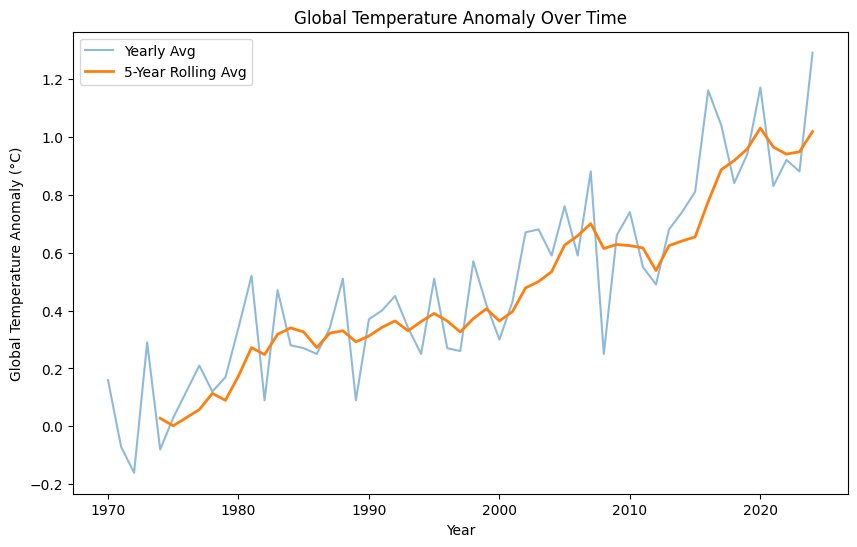

In [359]:
global_yearly = (
    merged_df.groupby("year", as_index=False)["global_temp"]
    .mean()
)

global_yearly["temp_smooth"] = global_yearly["global_temp"].rolling(window=5).mean()

plt.figure(figsize=(10,6))
plt.plot(global_yearly["year"], global_yearly["global_temp"], alpha=0.5, label="Yearly Avg")
plt.plot(global_yearly["year"], global_yearly["temp_smooth"], linewidth=2, label="5-Year Rolling Avg")

plt.xlabel("Year")
plt.ylabel("Global Temperature Anomaly (°C)")
plt.title("Global Temperature Anomaly Over Time")
plt.legend()
plt.show()

# 3. Sea Level Trend Over Time

This graph shows the trend in sea level over time based on measurements from a Louisiana coastal station. The overall pattern shows a positive upward trend.

The 5-year rolling average makes this trend more visible by reducing short-term variability. This upward movement suggests that sea levels are rising over time, which is consistent with scientific research on climate change.

This graph is important because sea level is the dependent variable in the model. Understanding its long-term behavior helps determine whether other variables, such as global temperature and precipitation, can explain or predict these changes. The increasing trend also reinforces the importance of studying factors that contribute to sea level rise.

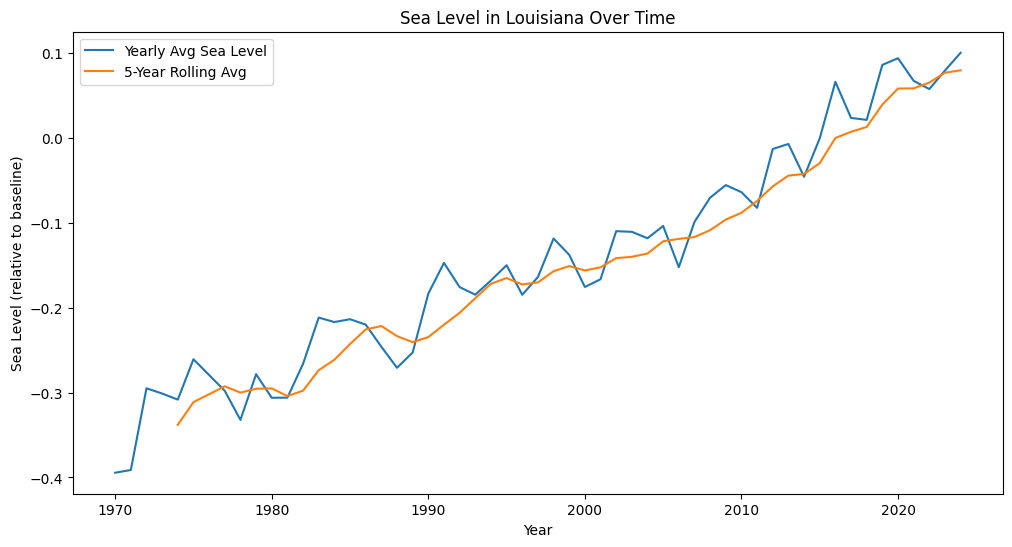

In [360]:
sea_yearly = (
    merged_df.groupby("year", as_index=False)["sea_level"]
    .mean()
    .sort_values("year")
)

sea_yearly["sea_smooth"] = sea_yearly["sea_level"].rolling(window=5).mean()

plt.figure(figsize=(12,6))
plt.plot(sea_yearly["year"], sea_yearly["sea_level"], label="Yearly Avg Sea Level")
plt.plot(sea_yearly["year"], sea_yearly["sea_smooth"], label="5-Year Rolling Avg")
plt.xlabel("Year")
plt.ylabel("Sea Level (relative to baseline)")
plt.title("Sea Level in Louisiana Over Time")
plt.legend()
plt.show()

# 4. Precipitation Over Time

This graph shows the trend in yearly precipitation in Louisiana over time. The values fluctuate significantly from year to year, indicating that rainfall is more variable and less consistent than temperature or sea level trends.

This lack of a steady increase is expected because precipitation is influenced by short-term weather patterns, such as storms and seasonal conditions, rather than long-term warming alone. While climate change is strongly associated with rising temperatures and sea levels, its impact on precipitation is more complex and does not necessarily result in a consistent increase over time.

Overall, this graph suggests that precipitation does not follow the same long-term upward trend as temperature, highlighting that different environmental variables respond differently to climate change.

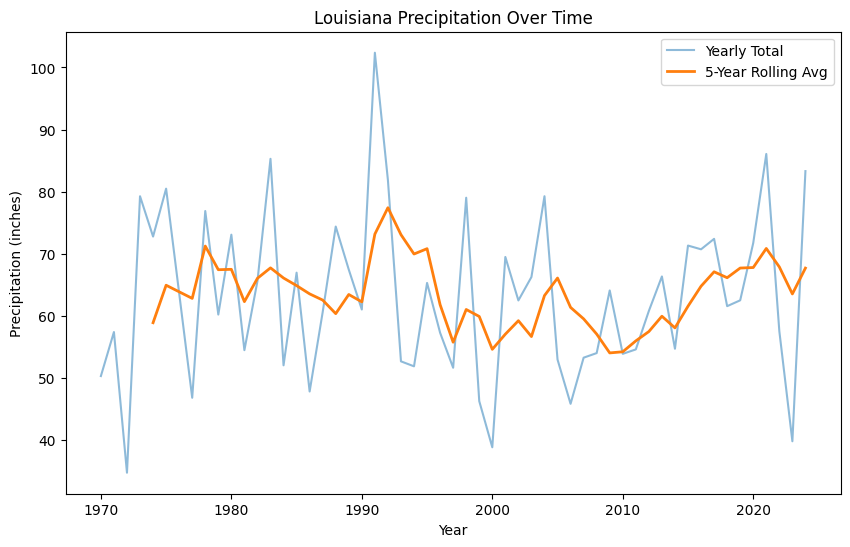

In [361]:
precip_yearly = (
    merged_df.groupby("year", as_index=False)["precipitation (inch)"]
    .sum()
)

precip_yearly["precip_smooth"] = precip_yearly["precipitation (inch)"].rolling(window=5).mean()

plt.figure(figsize=(10,6))
plt.plot(precip_yearly["year"], precip_yearly["precipitation (inch)"], alpha=0.5, label="Yearly Total")
plt.plot(precip_yearly["year"], precip_yearly["precip_smooth"], linewidth=2, label="5-Year Rolling Avg")

plt.xlabel("Year")
plt.ylabel("Precipitation (inches)")
plt.title("Louisiana Precipitation Over Time")
plt.legend()
plt.show()

Together, these graphs show that temperature and sea level exhibit upward trends over time, while precipitation remains highly variable. This suggests that not all environmental variables respond to long-term climate change in the same way.

# 5. Correlation Table

The correlation matrix reveals important relationships between the variables in this dataset. The strongest relationship is between global temperature and sea level, with a correlation of approximately 0.82. This indicates a strong positive relationship, meaning that as global temperature increases, sea level also tends to increase. This result aligns with expectations, as rising global temperatures contribute to sea level rise through thermal expansion of ocean water and melting ice.

In contrast, precipitation shows a very weak relationship with both sea level and global temperature. The correlation between precipitation and sea level is approximately 0.09, and the correlation between precipitation and global temperature is close to zero. These values suggest that precipitation does not have a strong or consistent impact on sea level in this dataset.

Overall, the correlation matrix supports the idea that global temperature is the most important predictor of sea level among the variables considered. While precipitation may contribute to short-term variability, it does not appear to play a significant role in explaining long-term sea level trends.

In [362]:
merged_df[["global_temp", "sea_level", "precipitation (inch)"]].corr()

,global_temp,sea_level,precipitation (inch)
global_temp,1.000000,0.817843,0.012616
sea_level,0.817843,1.000000,0.087092
precipitation (inch),0.012616,0.087092,1.000000


# 6. Relationship Between Global Temperature and Sea Level

This scatterplot shows the relationship between global temperature anomaly and sea level. Each point represents a paired observation of temperature anomaly and sea level for a given time period. The regression line provides a summary of the overall linear relationship between the two variables.

The plot shows a slight upward trend, suggesting that higher global temperature anomalies are associated with higher sea levels. While the points are somewhat spread out, the general direction of the regression line indicates a positive relationship.

This result supports the scientific expectation that rising global temperatures contribute to rising sea levels. However, the spread of the data also suggests that temperature alone does not fully explain sea level variation, meaning other factors may also play a role. This reinforces the need for a multivariable model.

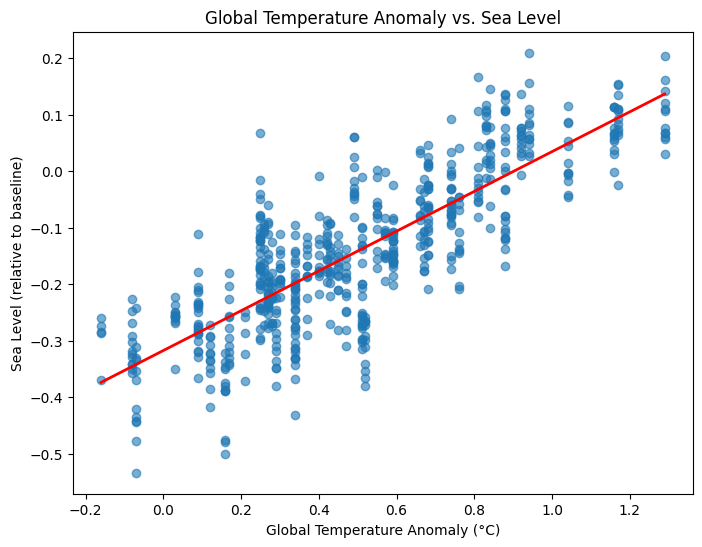

In [363]:
reg_df = merged_df[["global_temp", "sea_level"]].replace([np.inf, -np.inf], np.nan).dropna()
reg_df = reg_df.sort_values("global_temp")

x = reg_df["global_temp"]
y = reg_df["sea_level"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, m*x + b, color="red", linewidth=2)

plt.xlabel("Global Temperature Anomaly (°C)")
plt.ylabel("Sea Level (relative to baseline)")
plt.title("Global Temperature Anomaly vs. Sea Level")
plt.show()

# 7. Relationships Between Precipitation and Sea Level

This scatterplot shows the relationship between precipitation and sea level. Each point represents a monthly observation, and the red regression line summarizes the overall trend between the two variables.

The data points are widely dispersed, indicating a weak relationship between precipitation and sea level. While the regression line has a slight upward slope, the spread of the points suggests that precipitation does not strongly or consistently predict changes in sea level.

This is supported by the variability seen in the plot, where similar precipitation values correspond to a wide range of sea level values. This suggests that precipitation may contribute to short-term fluctuations in water levels, such as during heavy rainfall events, but it does not appear to be a major driver of long-term sea level change.

Overall, this graph indicates that precipitation is not a strong predictor of sea level compared to other variables, such as global temperature.

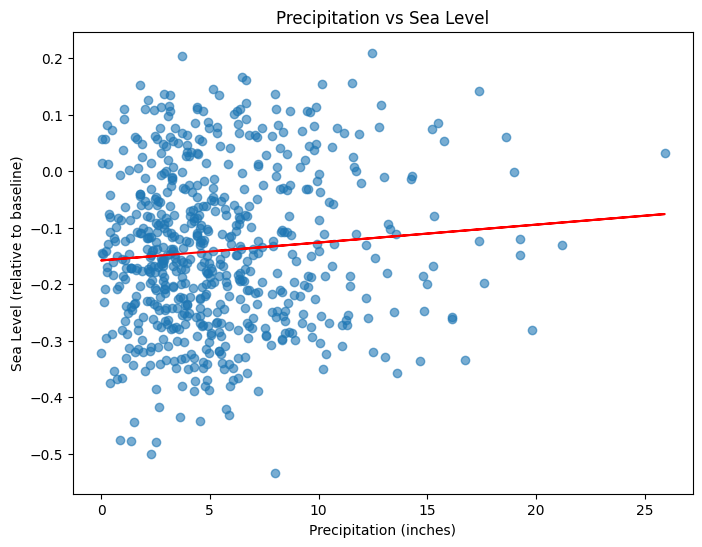

In [364]:
plt.figure(figsize=(8,6))
plt.scatter(merged_df["precipitation (inch)"], merged_df["sea_level"], alpha=0.6)

reg_df = merged_df[["precipitation (inch)", "sea_level"]].dropna()
x = reg_df["precipitation (inch)"]
y = reg_df["sea_level"]
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color="red")

plt.xlabel("Precipitation (inches)")
plt.ylabel("Sea Level (relative to baseline)")
plt.title("Precipitation vs Sea Level")
plt.show()

# **Research Questions**

This project addresses the following research questions:

## Primary Question
**Can global temperature anomaly and Louisiana precipitation predict sea level rise
along the Louisiana coast?**

- **Dependent Variable:** Monthly mean sea level (mm)
- **Independent Variables:**
  - Global temperature anomaly (°C)
  - Louisiana precipitation (inches)

## Secondary Questions
1. What is the strength of the relationship between global temperature and sea level?
2. Does precipitation contribute significantly to sea level prediction?
3. How well can we predict future sea level based on these climate variables?

**Modeling Approach:** We will use multiple regression models to answer these questions, including Linear Regression and Decision Tree Regression. We chose these models because linear regression is a simple and interpretable model that is effective for identifying linear relationships between variables, such as the relationship between global temperature and sea level. The decision tree model was selected as a comparison because it can capture more complex, nonlinear patterns in the data. By using both models, we can evaluate whether the relationship between the variables is primarily linear or if a more flexible model provides better predictive performance.

**Evaluation Method:** Model performance will be evaluated using R² score, RMSE, and
MAE to assess both explained variance and prediction accuracy.

# **Modeling**

The goal of this model is to predict sea level using global temperature and precipitation. Based on the exploratory data analysis, global temperature showed a strong positive relationship with sea level, while precipitation showed a much weaker relationship.

Global temperature was selected as the primary predictor because it reflects long-term climate change, which directly contributes to sea level rise through processes such as thermal expansion of ocean water and melting ice. Precipitation was included as a secondary variable to account for possible short-term fluctuations in water levels.



# Linear Regression Model

To test these relationships, a multiple linear regression model was used. This model estimates how changes in global temperature and precipitation are associated with changes in sea level.

The multiple linear regression model can be expressed as:

Sea Level = β₀ + β₁(Global Temperature) + β₂(Precipitation) + ε

Where:
- β₀ is the intercept
- β₁ and β₂ are coefficients for global temperature and precipitation
- ε represents the error term


In [365]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

Before building the model, the data is cleaned to remove missing or invalid values. This ensures the model is trained on consistent and usable data.

The dataset includes global temperature and precipitation as predictors and sea level as the target variable.

In [366]:
# clean dataset
model_df = merged_df[["global_temp", "precipitation (inch)", "sea_level"]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

# define X and y
X = model_df[["global_temp", "precipitation (inch)"]]
y = model_df["sea_level"]

In [367]:
# create one clean modeling dataframe first
model_df = merged_df[["global_temp", "precipitation (inch)", "sea_level"]].copy()

# remove invalid values and missing rows
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna()

# define X and y from the SAME dataframe
X = model_df[["global_temp", "precipitation (inch)"]]
y = model_df["sea_level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (631, 2)
y shape: (631,)


The data is split into training and testing sets to evaluate how well the model performs on unseen data.

In [368]:
# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train model
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Linear Regression Performance:
Mean Squared Error: 0.006173890290629437
Mean Absolute Error: 0.06042963393679383
R² Score: 0.6693803958935112


# Linear Regression Visualization


This graph compares the actual sea level values to the values predicted by the model. If the model were perfectly accurate, all points would lie directly on the red diagonal line.

The points generally follow the direction of the line, indicating that the model is capturing the overall trend in the data. However, there is still some spread, meaning the model does not perfectly predict every value. This suggests that while the model performs reasonably well, other factors not included in the model may also influence sea level.

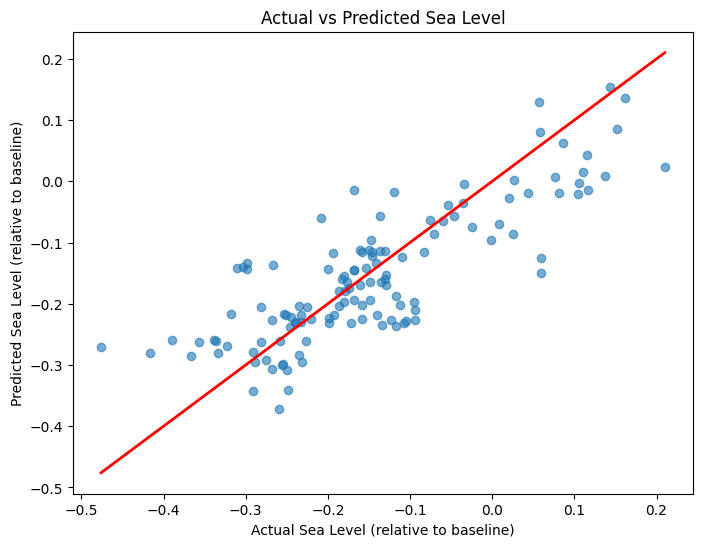

In [369]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sea Level (relative to baseline)")
plt.ylabel("Predicted Sea Level (relative to baseline)")
plt.title("Actual vs Predicted Sea Level")

plt.show()

## Decision Tree Regression Model

In addition to multiple linear regression, a decision tree regression model is used to further analyze the relationship between global temperature, precipitation, and sea level. Unlike linear regression, which assumes a linear relationship, a decision tree can capture nonlinear patterns in the data.

This model is included to compare performance and determine whether a more flexible approach improves prediction accuracy for sea level.

In [370]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# initialize decision tree model
# max_depth controls how complex the tree is (prevents overfitting)
dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)

# train the model using training data
dt_model.fit(X_train, y_train)

# make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# evaluate model performance
print("Decision Tree Performance:")
print(f"R² Score: {r2_score(y_test, y_pred_dt):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_dt):.4f}")

Decision Tree Performance:
R² Score: 0.7345
RMSE: 0.0704
MAE: 0.0549


The decision tree model provides an alternative approach to predicting sea level by allowing for nonlinear relationships between variables. The R² score indicates how well the model explains variation in sea level, while RMSE and MAE measure the average prediction error.

Comparing these results to the linear regression model helps determine whether the relationship between global temperature and sea level is primarily linear or if more complex patterns exist. If the decision tree does not significantly outperform linear regression, this suggests that a simple linear relationship is sufficient to describe the data.

## Decision Tree Visualization

To better understand how the decision tree model makes predictions, the structure of the tree is visualized below. Each split represents a decision based on one of the input variables, showing how the model partitions the data to predict sea level.

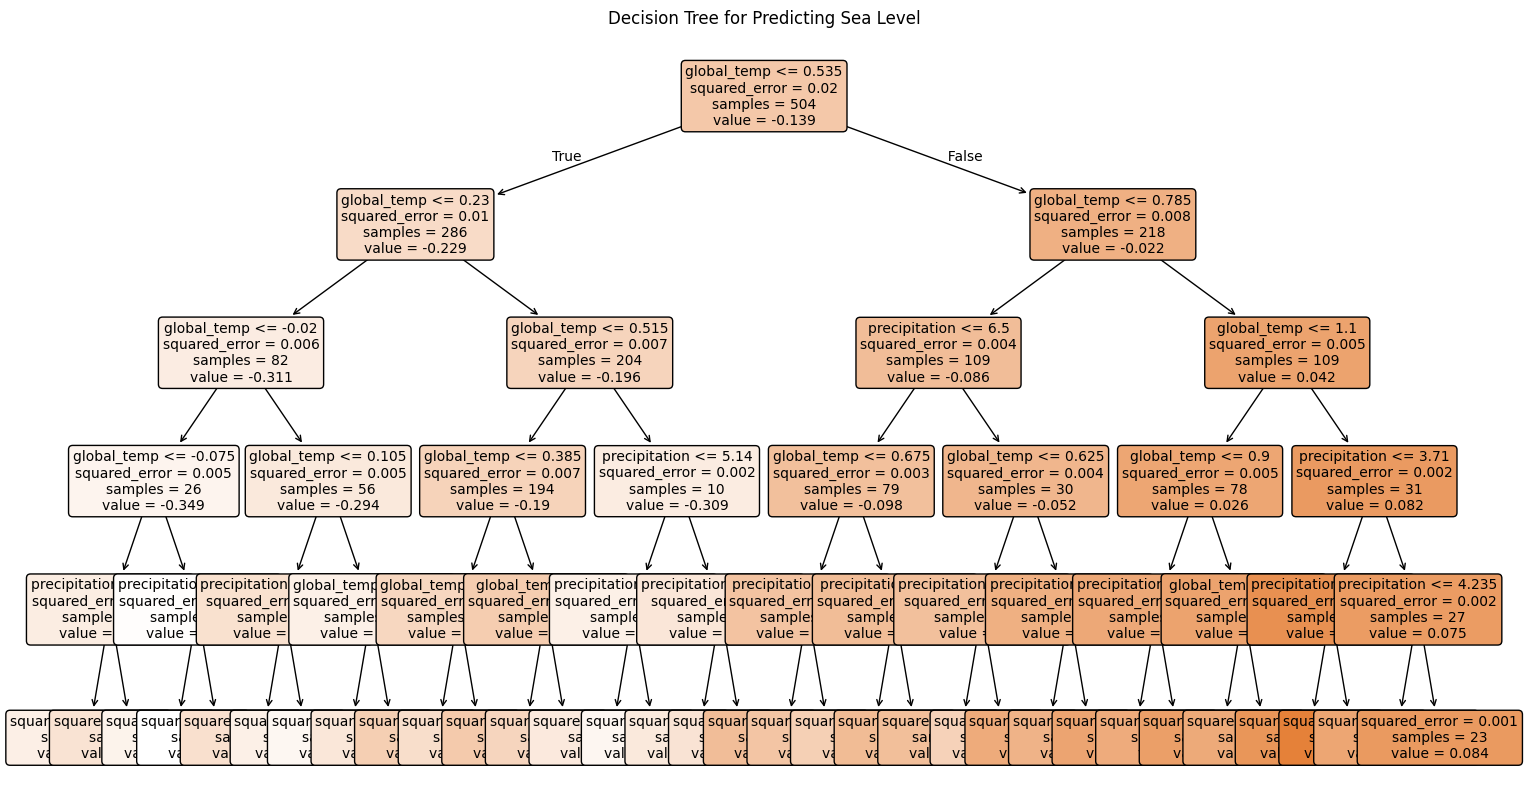

In [371]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# create figure for the tree
plt.figure(figsize=(18,10))

# plot the trained decision tree
plot_tree(
    dt_model,  # trained model
    feature_names=["global_temp", "precipitation"],  # input variables
    filled=True,  # color nodes based on values
    rounded=True,  # rounded edges for readability
    fontsize=10
)

# add title
plt.title("Decision Tree for Predicting Sea Level")

# display graph
plt.show()

The decision tree visualization shows how the model uses global temperature and precipitation to make predictions. The tree splits overwhelmingly on global temperature at nearly every level, indicating that it is the dominant variable driving predictions of sea level.

Precipitation appears only occasionally in the lower branches of the tree, which supports earlier findings that it has a much weaker relationship with sea level. This suggests that precipitation contributes very little to improving the model’s predictions compared to temperature.

The structure of the tree also shows that the model creates different prediction regions based on ranges of global temperature, allowing it to capture nonlinear patterns in how temperature influences sea level.

Overall, the visualization strongly reinforces the conclusion that global temperature is the primary factor influencing sea level, while precipitation plays only a minor and secondary role.

# **Model Comparison**

To determine which model better predicts sea level, the performance of the multiple linear regression model and the decision tree regression model are compared using several evaluation metrics.

In [372]:
# create comparison table
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "R² Score": [r2, r2_score(y_test, y_pred_dt)],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_dt)
    ]
})

model_results

,Model,R² Score,RMSE,MAE
0,Linear Regression,0.669380,0.078574,0.060430
1,Decision Tree,0.734527,0.070409,0.054903


The comparison table shows that the decision tree model slightly outperforms the linear regression model across all evaluation metrics. It has a higher R² score, indicating that it explains more variation in sea level, and lower RMSE and MAE values, meaning its predictions are more accurate on average.

This suggests that while the relationship between global temperature and sea level is strong, it may not be perfectly linear. The decision tree model is able to capture small nonlinear patterns that the linear regression model cannot.

However, the improvement in performance is relatively modest, which indicates that a linear model still provides a reasonable approximation of the relationship. Overall, both models support the conclusion that global temperature is a strong predictor of sea level, while precipitation has limited influence.

# **Conclusions and Insights**

## Key Findings

1. **Global Temperature is a Strong Predictor**
   - R² = 0.67 means approximately 67% of the variation in sea level is explained by global temperature and precipitation
   - Global temperature alone accounts for most of this explanatory power (r = 0.82)
   - This supports the scientific understanding that rising global temperatures contribute to sea level rise through thermal expansion and melting ice

2. **Precipitation Has Minimal Impact**
   - Very weak correlation with sea level (r = 0.09)
   - This suggests precipitation does not significantly influence long-term sea level trends
   - Sea level rise is driven primarily by global processes rather than local rainfall patterns

3. **Model Performance**
   - The decision tree model performed slightly better than linear regression
   - Decision Tree: R² = 0.73, RMSE = 0.070, MAE = 0.055  
   - Linear Regression: R² = 0.67, RMSE = 0.079, MAE = 0.060  
   - This indicates that allowing for nonlinear relationships slightly improves prediction accuracy


## Unexpected Insights

- We initially used Louisiana temperature data, but switching to global temperature significantly improved model performance  
- The strong relationship between global temperature and sea level confirms that sea level rise is influenced by large-scale climate trends rather than local conditions  
- The decision tree model revealed that temperature plays a dominant role, while precipitation contributes very little to predictions  


## Limitations

- The model only includes two predictors; other important variables such as ice melt rates and ocean circulation are not included  
- The dataset is time-based, but the models used do not explicitly account for time dependencies  
- Local sea level in Louisiana may also be affected by land subsidence, which is not captured in this analysis  


## Implications for Louisiana

Rising sea levels pose significant risks to coastal Louisiana communities. The results suggest that increases in global temperature are strongly associated with rising sea levels, meaning Louisiana will likely continue to experience sea level rise even if local weather patterns, such as precipitation, remain stable.


## Future Directions

- Incorporate additional variables such as ice melt data and ocean temperature  
- Explore time series models (such as ARIMA) to better capture trends over time  
- Include land subsidence data specific to Louisiana  
- Use the model to predict future sea levels under different climate scenarios  

# **Further Resources**

For readers interested in learning more about the data, methods, and concepts used in this project, the following resources provide helpful explanations and deeper insight:

- **NOAA Climate Data (Data Source Used in This Project)**  
  https://www.noaa.gov  
  This is the official source of the climate datasets used in this project. NOAA provides long-term records of temperature, precipitation, and sea level, which are widely used in scientific research. Exploring this site can help readers better understand where the data comes from and how it is collected.

- **NOAA Climate at a Glance (Understanding Temperature Anomalies)**  
  https://www.ncei.noaa.gov/access/monitoring/climate-at-a-glance/  
  This tool allows users to explore global and regional temperature trends over time. It is especially useful for understanding temperature anomaly data, which was used as a key variable in this project.

- **NASA Climate Change: Sea Level**  
  https://climate.nasa.gov/vital-signs/sea-level/  
  This resource explains the science behind sea level rise, including thermal expansion and melting ice sheets. It helps connect the data analysis in this project to real-world environmental processes.

- **Linear Regression Explained (Conceptual Guide)**  
  https://towardsdatascience.com/linear-regression-explained-7efb3f66a3c2  
  This article provides a simple explanation of linear regression, including how models learn relationships between variables. It is helpful for readers who are new to machine learning.

- **Correlation vs. Causation (Important Concept)**  
  https://www.tylervigen.com/spurious-correlations  
  This resource demonstrates why correlation does not always imply causation. It is relevant to this project because even though global temperature and sea level are strongly correlated, the relationship must still be interpreted carefully.

In [373]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1425051 bytes to /content/drive/MyDrive/Data Colab Notebooks/Elina_Mia_Final.html
